# LASSO Regression (LA) on the MALL 5-min Feature Set


**Purpose:** The purpose of this notebook is to compute the out-of-sample forecast performance of the LASSO (Least Absolute Shrinkage and Selection Operator) regression model on the $\mathcal{M}_{\mathrm{ALL}}$ 5-min feature set for the EURO STOXX 50 index over the period 1999--2020, following the methodology of Christensen et al. (2023).

The LASSO model extends the MHAR specification by introducing an $L_1$-penalty on the slope coefficients, which performs both shrinkage and variable selection. This is particularly useful when working with a broader macro-financial feature set that may contain correlated predictors.

The final MALL feature set used in this notebook is:

- `RVD`, `RVW`, `RVM`
- `VSTOXX`
- `CISS`
- `logEPU_1m_lag`
- `EURUSD_ret`
- `BRENT_ret`
- `NIKKEI_ret`, `NIKKEI_sq`
- `SP500_ret_lag`, `SP500_sq_lag`
- `M1W`, `M1M`

The model is estimated using a rolling forecasting scheme with a fixed train/validation/test split (70/10/20). At each step, the optimal penalty parameter is selected based on validation-set performance, and a one-day-ahead forecast is generated throughout the test period to evaluate out-of-sample accuracy.


## 1. Loading Data
Loading in data from the `MALL_5min.csv` file.


In [4]:
import pandas as pd
import numpy as np
import os
import time
import matplotlib.pyplot as plt
from sklearn.linear_model import Lasso

# Load MALL dataset
file_path = "/Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/5-min RV/Cleaned Data Sets/MALL_5min.csv"
MALL = pd.read_csv(file_path, index_col="Date", parse_dates=True)

print(f"Shape: {MALL.shape}")
print(f"Date range: {MALL.index[0].date()} to {MALL.index[-1].date()}")
print(f"NaN values: {MALL.isna().sum().sum()}")
MALL.head()


Shape: (5489, 31)
Date range: 1999-01-05 to 2020-08-06
NaN values: 0


,RVD,RVW,RVM,logRVD,logRVW,logRVM,RVD_pos,RVD_neg,RD_neg,RW_neg,...,BRENT,BRENT_ret,NIKKEI_ret,NIKKEI_sq,SP500_ret_lag,SP500_sq_lag,M1W,M1M,RV_target,logRV_target
Date,,,,,,,,,,,,,,,,,,,,,
1999-01-05,0.000106,0.000089,0.000141,-9.153100,-9.328531,-8.866447,0.000071,0.000035,0.000000,0.000000,...,10.30,-0.060282,-0.013746,0.000189,-0.000920,8.458434e-07,0.087690,0.126206,0.000047,-9.966398
1999-01-06,0.000047,0.000090,0.000132,-9.966398,-9.316927,-8.935760,0.000038,0.000009,0.000000,0.000000,...,10.67,0.035292,0.017657,0.000312,0.013491,1.819949e-04,0.100143,0.187219,0.000237,-8.347779
1999-01-07,0.000237,0.000123,0.000131,-8.347779,-9.004761,-8.938374,0.000110,0.000127,-0.012859,0.000000,...,11.08,0.037706,0.005044,0.000025,0.021899,4.795626e-04,0.078881,0.184020,0.000168,-8.689606
1999-01-08,0.000168,0.000146,0.000114,-8.689606,-8.832472,-9.082830,0.000079,0.000089,-0.005883,0.000000,...,11.70,0.054447,-0.010751,0.000116,-0.002053,4.216638e-06,0.078883,0.165510,0.000282,-8.175339
1999-01-11,0.000282,0.000168,0.000117,-8.175339,-8.692020,-9.056351,0.000067,0.000215,-0.025309,-0.001398,...,12.07,0.031134,-0.001744,0.000003,0.004212,1.774503e-05,0.001055,0.140613,0.000191,-8.565468


## 2. Data Split
### 2.1 Train / Validation / Test Split (70 / 10 / 20)


Following Christensen et al. (2023), we split the sample into a training set (70%), validation set (10%), and test set (20%). The test set is reserved exclusively for out-of-sample evaluation and no estimation or tuning is conducted on it.


In [8]:
# Train / Validation / Test split (70 / 10 / 20)
n = len(MALL)
n_train = int(np.floor(0.70 * n))
n_val   = int(np.floor(0.10 * n))
n_test  = n - n_train - n_val

train_idx = MALL.index[:n_train]
val_idx   = MALL.index[n_train:n_train + n_val]
test_idx  = MALL.index[n_train + n_val:]

print(f"Total observations: {n}")
print(f"\nTrain:      {train_idx[0].date()} to {train_idx[-1].date()} ({n_train} obs, {n_train/n*100:.1f}%)")
print(f"Validation: {val_idx[0].date()} to {val_idx[-1].date()} ({n_val} obs, {n_val/n*100:.1f}%)")
print(f"Test:       {test_idx[0].date()} to {test_idx[-1].date()} ({n_test} obs, {n_test/n*100:.1f}%)")


Total observations: 5489

Train:      1999-01-05 to 2014-02-26 (3842 obs, 70.0%)
Validation: 2014-02-27 to 2016-04-20 (548 obs, 10.0%)
Test:       2016-04-21 to 2020-08-06 (1099 obs, 20.0%)


## 3. LASSO Regression
### 3.1 Model Specification


The LASSO regression model extends the baseline HAR specification by introducing an $L_1$-penalty on the slope coefficients while allowing a broader MALL information set to enter the forecasting equation. The model is defined as:

$$
RV_{t+1} = \beta_0 + X_t \beta + \varepsilon_{t+1}
$$

where the coefficients are estimated by solving the regularized least squares problem:

$$
\min_{\beta_0,\beta}
\left\{
\sum_{t=1}^{T}
\left(RV_{t+1} - \beta_0 - X_t \beta\right)^2
+ \lambda \sum_{j=1}^{p} |\beta_j|
\right\},
$$

with $\lambda \geq 0$ denoting the LASSO penalty parameter that controls the degree of shrinkage applied to the coefficients.


### 3.2 Feature Set Construction
Extracting the dependent and independent variables relevant for the LA model.


In [13]:
# Define target and final MALL feature set
feature_cols = [
    "RVD", "RVW", "RVM",
    "VSTOXX", "CISS", "logEPU_1m_lag",
    "EURUSD_ret", "BRENT_ret",
    "NIKKEI_ret", "NIKKEI_sq",
    "SP500_ret_lag", "SP500_sq_lag",
    "M1W", "M1M"
]

y = MALL["RV_target"].values
X_MALL = MALL[feature_cols].values

# Split indices only — no standardization here
# Standardization will be applied inside the rolling window loop
# using only the training portion of each window

y_train = y[:n_train]
y_val   = y[n_train:n_train + n_val]
y_test  = y[n_train + n_val:]

print("Feature set:")
for col in feature_cols:
    print(f"  - {col}")
print(f"\nTraining set:   X={X_MALL[:n_train].shape}, y={y_train.shape}")
print(f"Validation set: X={X_MALL[n_train:n_train+n_val].shape}, y={y_val.shape}")
print(f"Test set:       X={X_MALL[n_train+n_val:].shape}, y={y_test.shape}")
print(f"\nTarget mean (train): {y_train.mean():.6e}")
print(f"Target std  (train): {y_train.std(ddof=0):.6e}")
print(f"Target range:        [{y_train.min():.6e}, {y_train.max():.6e}]")


Feature set:
  - RVD
  - RVW
  - RVM
  - VSTOXX
  - CISS
  - logEPU_1m_lag
  - EURUSD_ret
  - BRENT_ret
  - NIKKEI_ret
  - NIKKEI_sq
  - SP500_ret_lag
  - SP500_sq_lag
  - M1W
  - M1M

Training set:   X=(3842, 14), y=(3842,)
Validation set: X=(548, 14), y=(548,)
Test set:       X=(1099, 14), y=(1099,)

Target mean (train): 1.608657e-04
Target std  (train): 2.992674e-04
Target range:        [3.910328e-08, 9.794934e-03]


## Step 5: Rolling Window Estimation and Forecasting

Following Christensen et al. (2023), LASSO is estimated in a fixed-length rolling one-step-ahead forecasting exercise. At each forecast origin, the predictors are standardized using moments computed exclusively from the training portion of the current window, and the regularization parameter lambda is selected by minimizing validation-set MSE. In this thesis implementation, the logarithmic alpha grid is extended toward very small values so that the optimum is not artificially forced away from the near-unregularized region when the EURO STOXX 50 MALL specification prefers little shrinkage. Negative forecasts are replaced with the minimum realized variance observed in the rolling training window.


In [16]:
from sklearn.linear_model import Lasso

# Thesis-specific alpha grid: extended toward very small values so that
# the optimum is not forced away from the near-unregularized region
alpha_grid = np.logspace(-10, 1, 1000)

window_size  = n_train + n_val
forecasts_LA = []
dates_test   = []
best_alphas  = []
nonzero_path = []

start_time = time.time()

for i in range(n_test):
    # --- Define rolling window ---
    X_window = X_MALL[i:i + window_size]
    y_window = y[i:i + window_size]

    X_win_train = X_window[:n_train]
    X_win_val   = X_window[n_train:]
    y_win_train = y_window[:n_train]
    y_win_val   = y_window[n_train:]

    # --- Window-level feature standardization ---
    X_mean_w = X_win_train.mean(axis=0)
    X_std_w  = X_win_train.std(axis=0, ddof=0)
    X_std_w  = np.where(X_std_w == 0, 1.0, X_std_w)

    X_win_train_s = (X_win_train - X_mean_w) / X_std_w
    X_win_val_s   = (X_win_val   - X_mean_w) / X_std_w

    # --- Forecast point ---
    X_fore   = X_MALL[i + window_size].reshape(1, -1)
    X_fore_s = (X_fore - X_mean_w) / X_std_w

    # --- Hyperparameter tuning on validation set ---
    best_mse_w   = np.inf
    best_alpha_w = None

    for alpha in alpha_grid:
        model = Lasso(
            alpha=alpha,
            fit_intercept=True,
            max_iter=100000
        )
        model.fit(X_win_train_s, y_win_train)
        y_pred_val = model.predict(X_win_val_s)
        mse_w = np.mean((y_win_val - y_pred_val) ** 2)

        if mse_w < best_mse_w:
            best_mse_w   = mse_w
            best_alpha_w = alpha

    # --- Refit on the rolling training sample with best alpha ---
    final_model = Lasso(
        alpha=best_alpha_w,
        fit_intercept=True,
        max_iter=100000
    )
    final_model.fit(X_win_train_s, y_win_train)

    # --- Sparsity tracking ---
    n_nonzero = np.sum(np.abs(final_model.coef_) > 1e-12)
    nonzero_path.append(n_nonzero)

    # --- Generate forecast and apply paper-consistent floor ---
    forecast_orig = final_model.predict(X_fore_s)[0]
    min_rv_roll = y_win_train.min()
    forecast_orig = max(forecast_orig, min_rv_roll)

    forecasts_LA.append(forecast_orig)
    dates_test.append(MALL.index[i + window_size])
    best_alphas.append(best_alpha_w)

    if (i + 1) % 100 == 0:
        elapsed = (time.time() - start_time) / 60
        print(f"  Day {i+1:4d}/{n_test} | "
              f"Date: {MALL.index[i + window_size].date()} | "
              f"Best alpha: {best_alpha_w:.2e} | "
              f"Non-zero coefs: {n_nonzero}/{len(feature_cols)} | "
              f"Elapsed: {elapsed:.1f} min")

total_elapsed = (time.time() - start_time) / 60
print(f"\nTotal estimation time: {total_elapsed:.1f} minutes")
print(f"Forecasts generated:   {len(forecasts_LA)}")
print(f"Forecast period:       {dates_test[0].date()} to {dates_test[-1].date()}")

print(f"\nAlpha path summary:")
alpha_series = pd.Series(best_alphas)
print(f"  Most common alpha: {alpha_series.mode()[0]:.2e}")
print(f"  Min alpha used:    {min(best_alphas):.2e}")
print(f"  Max alpha used:    {max(best_alphas):.2e}")
print(f"  Boundary hits (max): {(alpha_series >= alpha_grid[-1] * 0.999).sum()}")
print(f"  Boundary hits (min): {(alpha_series <= alpha_grid[0]  * 1.001).sum()}")

print(f"\nSparsity summary:")
nonzero_series = pd.Series(nonzero_path)
print(f"  Mean non-zero coefs:   {nonzero_series.mean():.2f} / {len(feature_cols)}")
print(f"  All coefs zero:        {(nonzero_series == 0).sum()} windows")
print(f"  All coefs nonzero:     {(nonzero_series == len(feature_cols)).sum()} windows")
print(f"  Partial sparsity:      {((nonzero_series > 0) & (nonzero_series < len(feature_cols))).sum()} windows")


  Day  100/1099 | Date: 2016-09-08 | Best alpha: 8.18e-05 | Non-zero coefs: 3/14 | Elapsed: 1.3 min
  Day  200/1099 | Date: 2017-01-27 | Best alpha: 7.78e-05 | Non-zero coefs: 3/14 | Elapsed: 2.6 min
  Day  300/1099 | Date: 2017-06-21 | Best alpha: 7.21e-05 | Non-zero coefs: 3/14 | Elapsed: 3.9 min
  Day  400/1099 | Date: 2017-11-08 | Best alpha: 6.51e-05 | Non-zero coefs: 3/14 | Elapsed: 5.2 min
  Day  500/1099 | Date: 2018-04-04 | Best alpha: 6.35e-05 | Non-zero coefs: 3/14 | Elapsed: 6.5 min
  Day  600/1099 | Date: 2018-08-22 | Best alpha: 3.82e-05 | Non-zero coefs: 5/14 | Elapsed: 7.8 min
  Day  700/1099 | Date: 2019-01-14 | Best alpha: 3.92e-05 | Non-zero coefs: 5/14 | Elapsed: 9.1 min
  Day  800/1099 | Date: 2019-06-06 | Best alpha: 4.45e-05 | Non-zero coefs: 4/14 | Elapsed: 10.4 min
  Day  900/1099 | Date: 2019-10-24 | Best alpha: 4.23e-05 | Non-zero coefs: 4/14 | Elapsed: 12.0 min
  Day 1000/1099 | Date: 2020-03-17 | Best alpha: 5.03e-06 | Non-zero coefs: 9/14 | Elapsed: 13.2 m

## Step 6: Save Forecasts and Evaluate Test Set Performance

We save the LASSO forecasts to disk and compute test set performance metrics, following the same structure as all other model notebooks to ensure consistency in the results aggregation. The forecast file is stored in the Regularized Linear Models directory alongside the Ridge and Elastic Net results.


In [20]:
# --- Define paths ---
forecast_path = "/Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/5-min RV/Cleaned Data Sets/Forecasts 5-min/MALL/Regularized Linear Models"
mse_path      = "/Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/5-min RV/Cleaned Data Sets/MSE 5-min/MALL/Regularized Linear Models"
os.makedirs(forecast_path, exist_ok=True)
os.makedirs(mse_path, exist_ok=True)

# --- Construct results dataframe ---
results_LA = pd.DataFrame({
    "RV_actual":   y_test,
    "RV_forecast": forecasts_LA
}, index=dates_test)

# --- Compute errors ---
errors_LA = results_LA["RV_actual"] - results_LA["RV_forecast"]
mse_LA    = np.mean(errors_LA ** 2)

# --- Save forecasts ---
results_LA.to_csv(os.path.join(forecast_path, "forecasts_LA.csv"))

# --- Save MSE summary ---
mse_summary_LA = pd.DataFrame({
    "Model":      ["LA"],
    "MSE":        [mse_LA],
    "RMSE":       [np.sqrt(mse_LA)],
    "MAE":        [errors_LA.abs().mean()],
    "Mean_Error": [errors_LA.mean()]
}).set_index("Model")
mse_summary_LA.to_csv(os.path.join(mse_path, "mse_summary_LA.csv"))

# --- Print summary ---
print(f"Forecasts saved to:   {forecast_path}")
print(f"MSE summary saved to: {mse_path}")
print(f"Rows saved: {len(results_LA)}")
print()
print(mse_summary_LA.to_string())


Forecasts saved to:   /Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/5-min RV/Cleaned Data Sets/Forecasts 5-min/MALL/Regularized Linear Models
MSE summary saved to: /Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/5-min RV/Cleaned Data Sets/MSE 5-min/MALL/Regularized Linear Models
Rows saved: 1099

                MSE      RMSE       MAE  Mean_Error
Model                                              
LA     5.077819e-08  0.000225  0.000054   -0.000013


## Step 8: Alpha Path Visualisation

We plot the evolution of the selected regularization parameter over the test period. This reveals how the degree of regularization varies across different market conditions and how often LASSO retains only a subset of the MALL predictors.


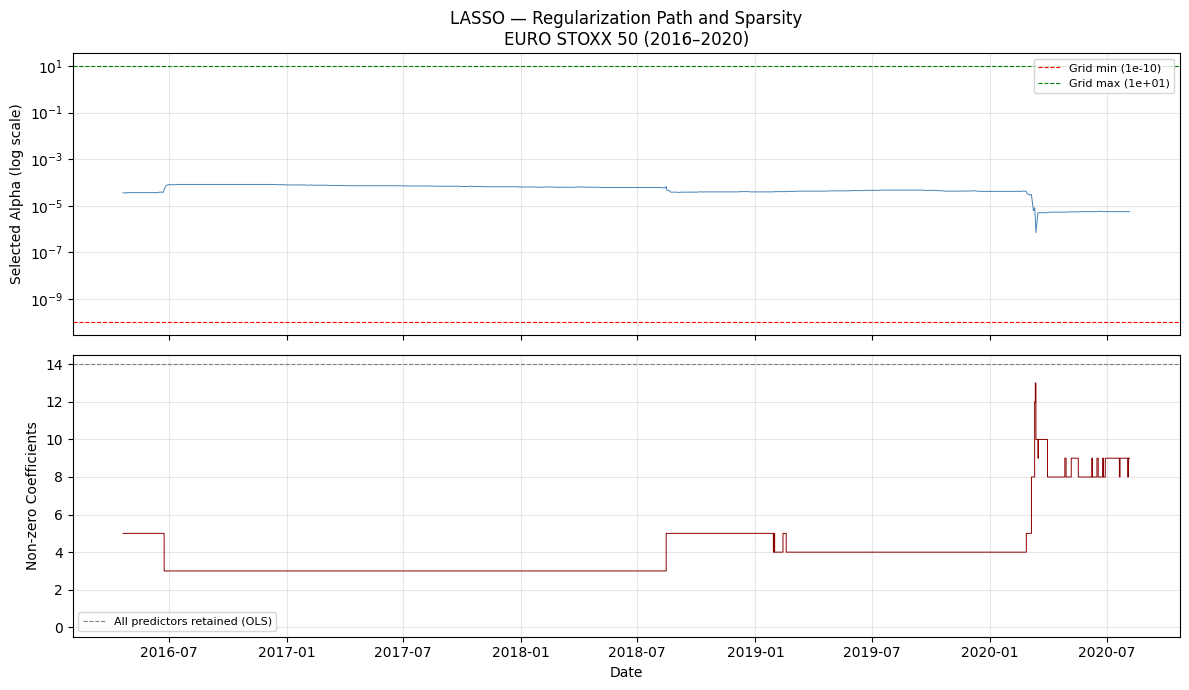

In [23]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

# --- Alpha path ---
axes[0].semilogy(dates_test, best_alphas, 
                  color="steelblue", linewidth=0.7)
axes[0].axhline(y=alpha_grid[0],  color="red",   
                linestyle="--", linewidth=0.8, 
                label=f"Grid min ({alpha_grid[0]:.0e})")
axes[0].axhline(y=alpha_grid[-1], color="green", 
                linestyle="--", linewidth=0.8, 
                label=f"Grid max ({alpha_grid[-1]:.0e})")
axes[0].set_ylabel("Selected Alpha (log scale)")
axes[0].set_title("LASSO — Regularization Path and Sparsity\nEURO STOXX 50 (2016–2020)")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# --- Sparsity path ---
axes[1].step(dates_test, nonzero_path, 
             color="darkred", linewidth=0.7)
axes[1].set_ylabel("Non-zero Coefficients")
axes[1].set_xlabel("Date")
axes[1].set_ylim(-0.5, len(feature_cols) + 0.5)
axes[1].axhline(y=len(feature_cols), color="grey", 
                linestyle="--", linewidth=0.8, 
                label="All predictors retained (OLS)")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 9. Results
### 9.1 Forecast Visualization


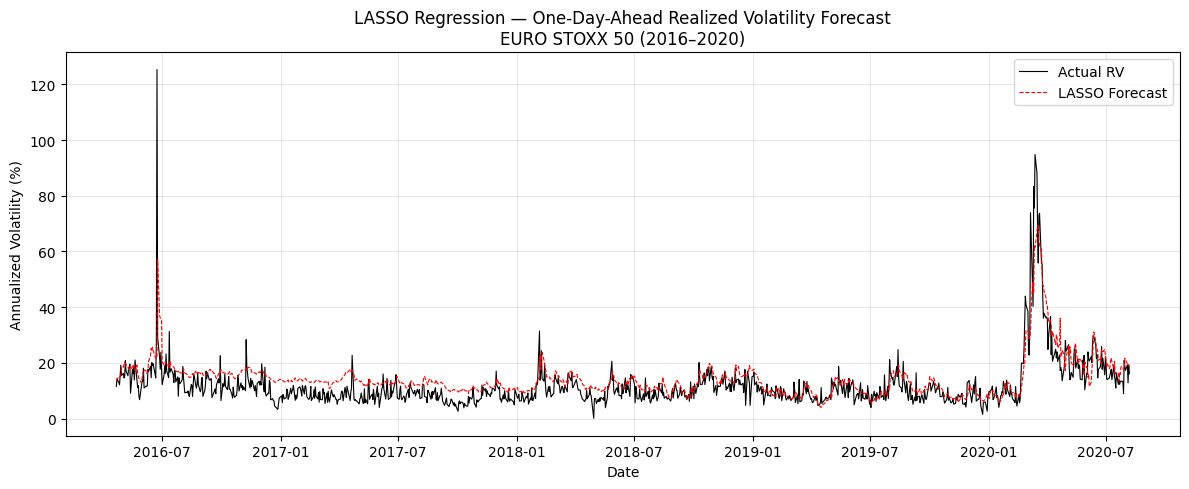


Summary of forecast errors:
Mean error:  -1.279487e-05
RMSE:        2.253402e-04
MAE:         5.398354e-05


In [26]:
import matplotlib.pyplot as plt

# Convert to annualized volatility for readability
results_plot = pd.DataFrame({
    "Actual":   np.sqrt(results_LA["RV_actual"] * 252) * 100,
    "Forecast": np.sqrt(results_LA["RV_forecast"] * 252) * 100
}, index=results_LA.index)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(results_plot["Actual"],   label="Actual RV",      color="black", linewidth=0.8)
ax.plot(results_plot["Forecast"], label="LASSO Forecast", color="red",   linewidth=0.8, linestyle="--")
ax.set_title("LASSO Regression — One-Day-Ahead Realized Volatility Forecast\nEURO STOXX 50 (2016–2020)", fontsize=12)
ax.set_ylabel("Annualized Volatility (%)")
ax.set_xlabel("Date")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nSummary of forecast errors:")
errors = results_LA["RV_actual"] - results_LA["RV_forecast"]
print(f"Mean error:  {errors.mean():.6e}")
print(f"RMSE:        {np.sqrt(mse_LA):.6e}")
print(f"MAE:         {errors.abs().mean():.6e}")
